In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from pathlib import Path
from scipy.signal import resample_poly



In [2]:
FS = 200                     # Sampling frequency (Hz)
WINDOW_SEC = 30              # Sliding window length (seconds)
WINDOW_SAMPLES = FS * WINDOW_SEC
STEP_SEC = 1                 # Step size for 1 Hz output


In [7]:

import warnings

pd.options.mode.copy_on_write = False
warnings.filterwarnings("ignore")

C:\Users\pat19\AppData\Local\Temp\ipykernel_21420\3878691399.py:3: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = False


In [3]:
def resample_signal(signal, fs_in=256, fs_out=200):

    return resample_poly(signal, fs_out, fs_in)

In [4]:
DATA_DIR = Path("../data/raw/Participants")

participant_files = sorted(
    DATA_DIR.rglob("full_gsr_ppg*.csv"),
    key=lambda x: int(x.parent.name.replace("Part", ""))
)

print("Antal filer:", len(participant_files))

Antal filer: 60


In [14]:
# välj EN participant
idx = 45   # ändra denna (0–47)

debug_file = participant_files[idx]

print("Analyserar:", debug_file)

df_debug = pd.read_csv(debug_file)

Analyserar: ..\data\raw\Participants\Part46\full_gsr_ppg.csv


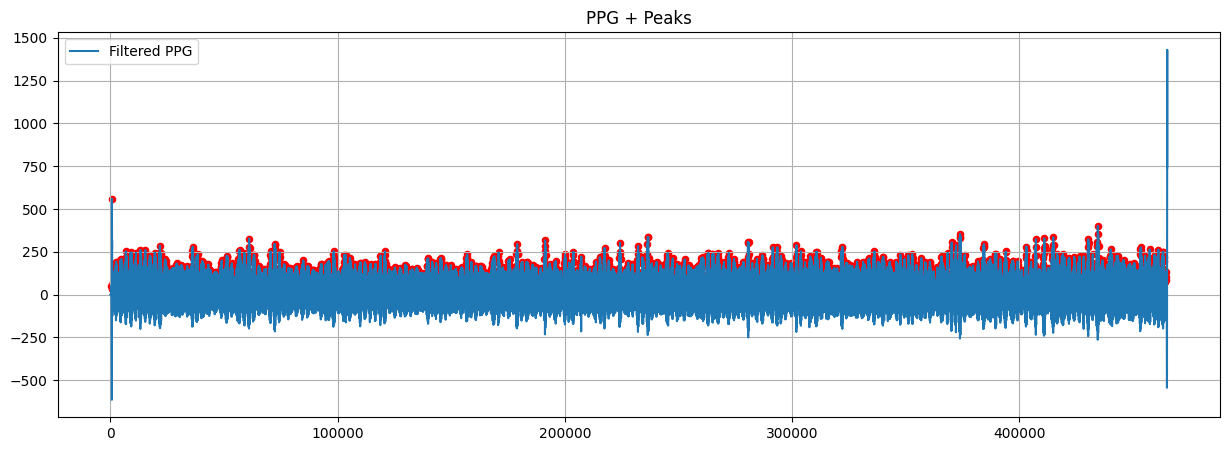

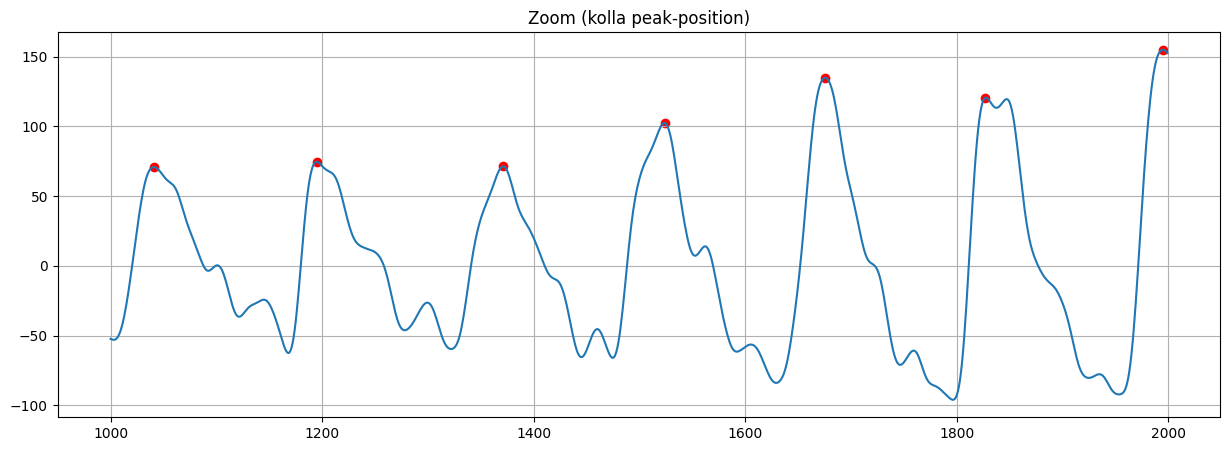

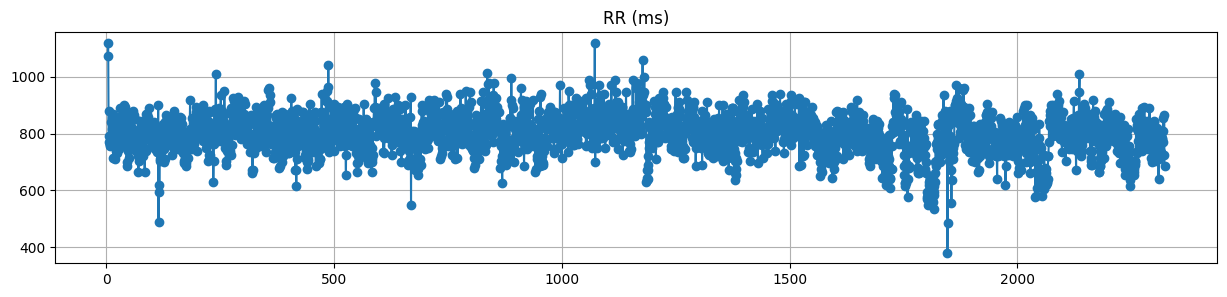

{'PPG_Peaks': array([   444,    659,    883, ..., 464394, 464567, 464704], shape=(2909,))}

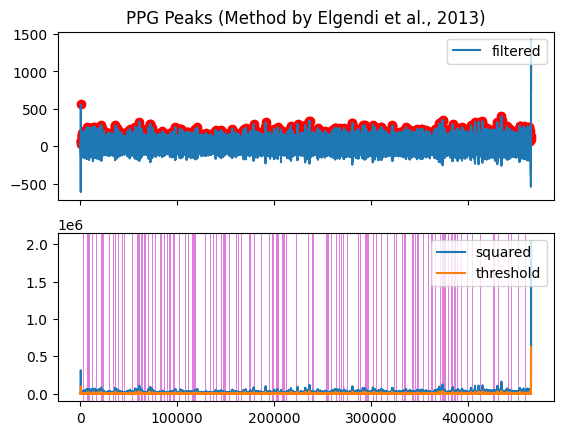

In [15]:
# =========================
# PREPROCESS (samma som din pipeline)
# =========================
ppg = pd.to_numeric(df_debug["ppg"], errors="coerce")
ppg = ppg.interpolate().bfill().ffill()
ppg = resample_signal(ppg.values, 256, 200)

# =========================
# NEUROKIT
# =========================
signals_ppg, info_ppg = nk.ppg_process(ppg, sampling_rate=FS)

rpeaks = info_ppg["PPG_Peaks"]

# RR
rr_intervals = np.diff(rpeaks) / FS * 1000
rr_times = (rpeaks[1:] + rpeaks[:-1]) / 2 / FS

# =========================
# PLOT 1: Signal + peaks
# =========================
plt.figure(figsize=(15,5))
plt.plot(signals_ppg["PPG_Clean"], label="Filtered PPG")

plt.scatter(
    rpeaks,
    signals_ppg["PPG_Clean"].iloc[rpeaks],
    color="red",
    s=20
)

plt.title("PPG + Peaks")
plt.grid()
plt.legend()
plt.show()

# =========================
# PLOT 2: Zoom (VIKTIGAST)
# =========================
start = 1000
end = 2000

plt.figure(figsize=(15,5))
segment = signals_ppg["PPG_Clean"].iloc[start:end]

plt.plot(segment)

peaks_window = [p for p in rpeaks if start <= p < end]

plt.scatter(
    peaks_window,
    signals_ppg["PPG_Clean"].iloc[peaks_window],
    color="red"
)

plt.title("Zoom (kolla peak-position)")
plt.grid()
plt.show()

# =========================
# PLOT 3: RR
# =========================
plt.figure(figsize=(15,3))
plt.plot(rr_times, rr_intervals, marker="o")

plt.title("RR (ms)")
plt.grid()
plt.show()

# =========================
# BONUS: hur NeuroKit tänker
# =========================
nk.ppg_findpeaks(
    signals_ppg["PPG_Clean"],
    sampling_rate=FS,
    show=True
)

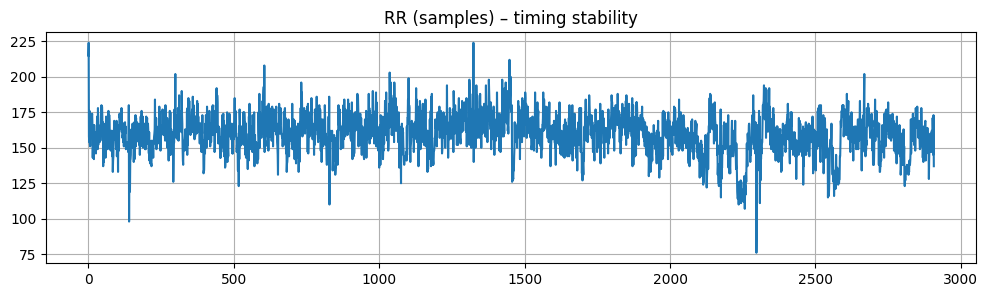

In [16]:
# RR i samples (inte ms)
rr_samples = np.diff(rpeaks)

plt.figure(figsize=(12,3))
plt.plot(rr_samples)
plt.title("RR (samples) – timing stability")
plt.grid()
plt.show()

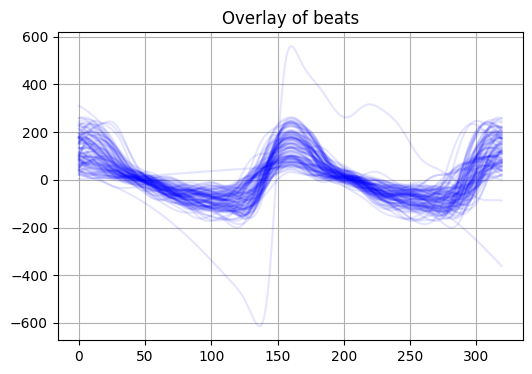

In [17]:
window = int(0.8 * FS)

beats = []

for p in rpeaks:
    if p > window and p + window < len(signals_ppg["PPG_Clean"]):
        beat = signals_ppg["PPG_Clean"].iloc[p-window:p+window].values
        beats.append(beat)

beats = np.array(beats)

plt.figure(figsize=(6,4))
for b in beats[:100]:
    plt.plot(b, alpha=0.1, color="blue")

plt.title("Overlay of beats")
plt.grid()
plt.show()

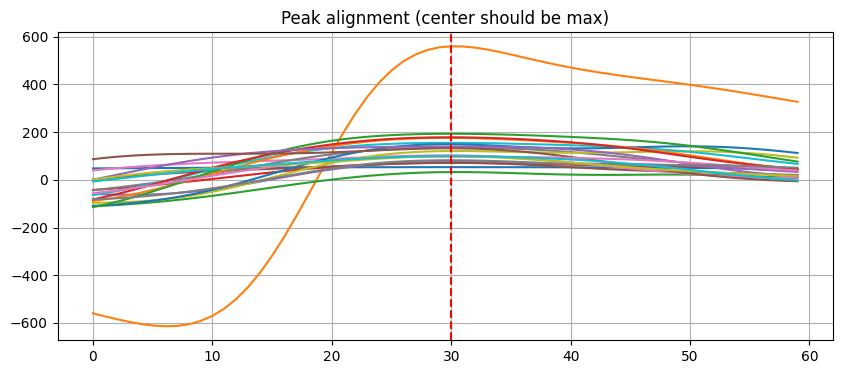

In [18]:
plt.figure(figsize=(10,4))

for i, p in enumerate(rpeaks[:20]):
    segment = signals_ppg["PPG_Clean"].iloc[p-30:p+30].values
    plt.plot(segment)

plt.axvline(30, color="red", linestyle="--")
plt.title("Peak alignment (center should be max)")
plt.grid()
plt.show()

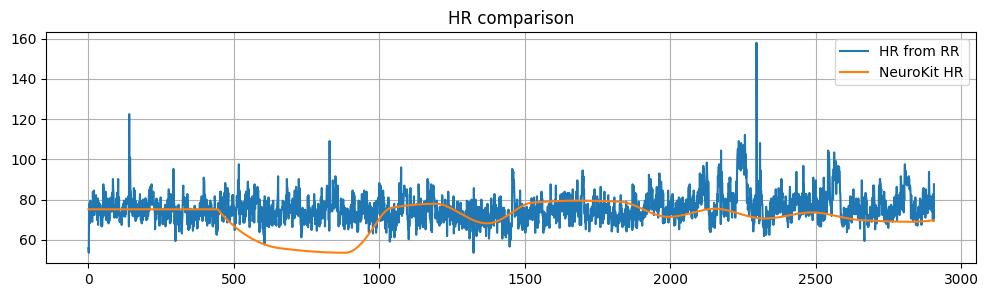

In [19]:
hr_from_rr = 60000 / rr_intervals

plt.figure(figsize=(12,3))
plt.plot(hr_from_rr, label="HR from RR")
plt.plot(signals_ppg["PPG_Rate"].values[:len(hr_from_rr)], label="NeuroKit HR")

plt.legend()
plt.title("HR comparison")
plt.grid()
plt.show()

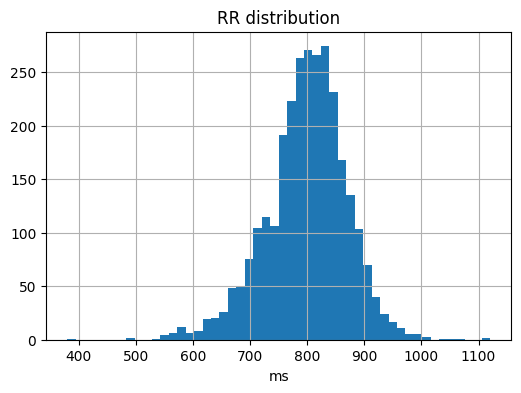

In [20]:
plt.figure(figsize=(6,4))
plt.hist(rr_intervals, bins=50)
plt.title("RR distribution")
plt.xlabel("ms")
plt.grid()
plt.show()

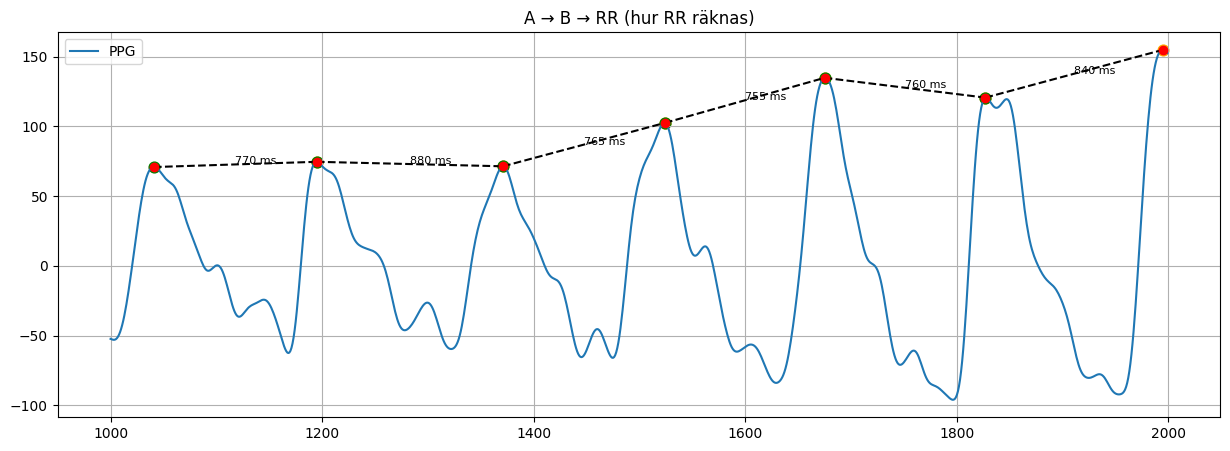

In [21]:
# =========================
# Välj ett intervall (zoom)
# =========================
start = 1000
end = 2000

signal = signals_ppg["PPG_Clean"]

# peaks i detta fönster
peaks_window = [p for p in rpeaks if start <= p < end]

plt.figure(figsize=(15,5))
plt.plot(signal.iloc[start:end], label="PPG")

# rita peaks
plt.scatter(
    peaks_window,
    signal.iloc[peaks_window],
    color="red",
    zorder=3
)

# =========================
# Rita A → B → RR
# =========================
for i in range(len(peaks_window) - 1):
    A = peaks_window[i]
    B = peaks_window[i+1]

    # markera A och B
    plt.scatter(A, signal.iloc[A], color="green", s=60)
    plt.scatter(B, signal.iloc[B], color="orange", s=60)

    # linje mellan A och B
    plt.plot(
        [A, B],
        [signal.iloc[A], signal.iloc[B]],
        linestyle="--",
        color="black"
    )

    # RR i ms
    rr_ms = (B - A) / FS * 1000

    # text mitt emellan
    mid_x = (A + B) / 2
    mid_y = (signal.iloc[A] + signal.iloc[B]) / 2

    plt.text(mid_x, mid_y, f"{rr_ms:.0f} ms", fontsize=8)

    # visa bara första 5 paren (så det inte blir rörigt)
    if i > 5:
        break

plt.title("A → B → RR (hur RR räknas)")
plt.grid()
plt.legend()
plt.show()